In [11]:
import matplotlib.pyplot as plt
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision

# **Parameter initialization and data preparation**

In [12]:
# Parameters
batch_size = 8
num_epochs = 10
device = 'cuda:0'
num_classes = 10

# Load dataset
transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torchvision.transforms.Normalize((0.5), (0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
valset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(trainset)

# Create dataloaders
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                         shuffle=False)

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )


In [13]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize to show images correctly
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

torch.Size([8, 3, 32, 32])


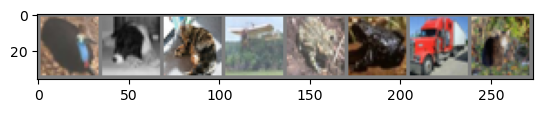

 bird   dog   cat plane  frog  frog truck   cat


In [14]:
# Print some samples of dataset as a sanity check

# Get some random training images
dataiter = iter(trainloader)
example_images, example_labels = next(dataiter)

print(example_images.shape)

# Show images
imshow(torchvision.utils.make_grid(example_images))
# Print labels
print(' '.join('%5s' % classes[example_labels[j]] for j in range(batch_size)))

# **Define Models**

In [15]:
class DenseNet(nn.Module):
    def __init__(self, input_features, num_classes):
        # Instantiation of layers and creation of trainable parameters
        super().__init__()
        self.flatten = nn.Flatten()
        self.dense1 = nn.Linear(input_features, 1024)
        self.dense2 = nn.Linear(1024, 512)
        self.dense3 = nn.Linear(512, 256)
        self.dense4 = nn.Linear(256, 64)
        self.dense5 = nn.Linear(64, num_classes)

    def forward(self, x):
        # Forward pass: the computations that are done on the input -> output
        x = self.flatten(x)
        x = F.relu(self.dense1(x))
        x = F.relu(self.dense2(x))
        x = F.relu(self.dense3(x))
        x = F.relu(self.dense4(x))
        x = self.dense5(x)
        return x

In [16]:
class ConvNet(nn.Module):
    def __init__(self, input_channels, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# **Make a training loop**

In [17]:
def compute_run_acc(logits, labels):
    _, pred = torch.max(logits.data, 1)
    return (pred == labels).sum().item()

In [18]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [19]:
# Instantiate model and optimizer

conv_net = True

if conv_net:
    model = ConvNet(3, num_classes).to(device)
    print("Convolutional model loaded")
    tr_accuracies_conv = np.zeros(num_epochs)
    val_accuracies_conv = np.zeros(num_epochs)
else:
    model = DenseNet(1024*3, num_classes).to(device)
    print("Dense model loaded")
    tr_accuracies_dense = np.zeros(num_epochs)
    val_accuracies_dense = np.zeros(num_epochs)
print("Number of trainable parameters: {}".format(count_parameters(model)))

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
best_val_acc = 0

start_time = time.time()

for epoch_nr in range(num_epochs):

    print("Epoch {}:".format(epoch_nr))

    # Train model
    running_loss = 0.0
    running_acc = 0.0
    for batch_data, batch_labels in trainloader:

        # Put data on device
        batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)

        # Predict and get loss
        logits = model(batch_data)
        loss = criterion(logits, batch_labels)

        # Update model
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += compute_run_acc(logits, batch_labels)
      
    # Print results
    tr_acc = 100 * running_acc/len(trainloader.dataset)
    print('>> TRAIN: Epoch {} completed | tr_loss: {:.4f} | tr_acc: {:.2f}%'.format(
        epoch_nr, running_loss/len(trainloader.dataset), tr_acc))
    
    # Get validation results
    running_acc = 0
    with torch.no_grad():
        for batch_data, batch_labels in valloader:
            batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)
            logits = model(batch_data)
            running_acc += compute_run_acc(logits, batch_labels)

    val_acc = 100 * running_acc/len(valloader.dataset)
    print('>> VALIDATION: Epoch {} | val_acc: {:.2f}%'.format(epoch_nr, val_acc))

    if conv_net:
        tr_accuracies_conv[epoch_nr] = tr_acc
        val_accuracies_conv[epoch_nr] = val_acc
    else:
        tr_accuracies_dense[epoch_nr] = tr_acc
        val_accuracies_dense[epoch_nr] = val_acc

    # Save model if best accuracy on validation dataset until now
    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(), './cifar_net.pth')
      print('>> SAVE: Epoch {} | Model saved'.format(epoch_nr))

end_time = time.time()
print('Finished Training in {:.2f} seconds'.format(end_time-start_time))

Convolutional model loaded
Number of trainable parameters: 62006
Epoch 0:
>> TRAIN: Epoch 0 completed | tr_loss: 0.2267 | tr_acc: 32.79%
>> VALIDATION: Epoch 0 | val_acc: 46.57%
>> SAVE: Epoch 0 | Model saved
Epoch 1:
>> TRAIN: Epoch 1 completed | tr_loss: 0.1716 | tr_acc: 50.45%
>> VALIDATION: Epoch 1 | val_acc: 52.78%
>> SAVE: Epoch 1 | Model saved
Epoch 2:
>> TRAIN: Epoch 2 completed | tr_loss: 0.1521 | tr_acc: 56.79%
>> VALIDATION: Epoch 2 | val_acc: 56.73%
>> SAVE: Epoch 2 | Model saved
Epoch 3:
>> TRAIN: Epoch 3 completed | tr_loss: 0.1404 | tr_acc: 60.29%
>> VALIDATION: Epoch 3 | val_acc: 60.51%
>> SAVE: Epoch 3 | Model saved
Epoch 4:
>> TRAIN: Epoch 4 completed | tr_loss: 0.1310 | tr_acc: 62.86%
>> VALIDATION: Epoch 4 | val_acc: 60.67%
>> SAVE: Epoch 4 | Model saved
Epoch 5:
>> TRAIN: Epoch 5 completed | tr_loss: 0.1234 | tr_acc: 65.02%
>> VALIDATION: Epoch 5 | val_acc: 63.10%
>> SAVE: Epoch 5 | Model saved
Epoch 6:
>> TRAIN: Epoch 6 completed | tr_loss: 0.1167 | tr_acc: 67.11%

In [20]:
plt.figure()
plt.plot(tr_accuracies_dense, label='Dense network')
plt.plot(tr_accuracies_conv, label='Conv network')
plt.title('Training results')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()

plt.figure()
plt.plot(val_accuracies_dense, label='Dense network')
plt.plot(val_accuracies_conv, label='Conv network')
plt.title('Validation results')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show()

NameError: name 'tr_accuracies_dense' is not defined

<Figure size 640x480 with 0 Axes>

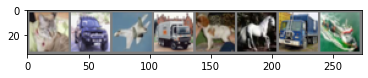

GT labels  :  cat   car plane truck   dog horse truck  ship
Predictions:  dog   car plane truck   dog horse truck  ship


In [ ]:
# Check some predictions from trained model

# Get some random validation images
dataiter = iter(valloader)
example_images, example_labels = next(dataiter)

# Show images
imshow(torchvision.utils.make_grid(example_images))
logits = model(example_images.to(device))
_, pred_classes = torch.max(logits.data, 1)

# Print labels
print('GT labels  :' + ' '.join('%5s' % classes[example_labels[j].item()] for j in range(batch_size)))
print('Predictions:' + ' '.join('%5s' % classes[pred_classes[j].item()] for j in range(batch_size)))